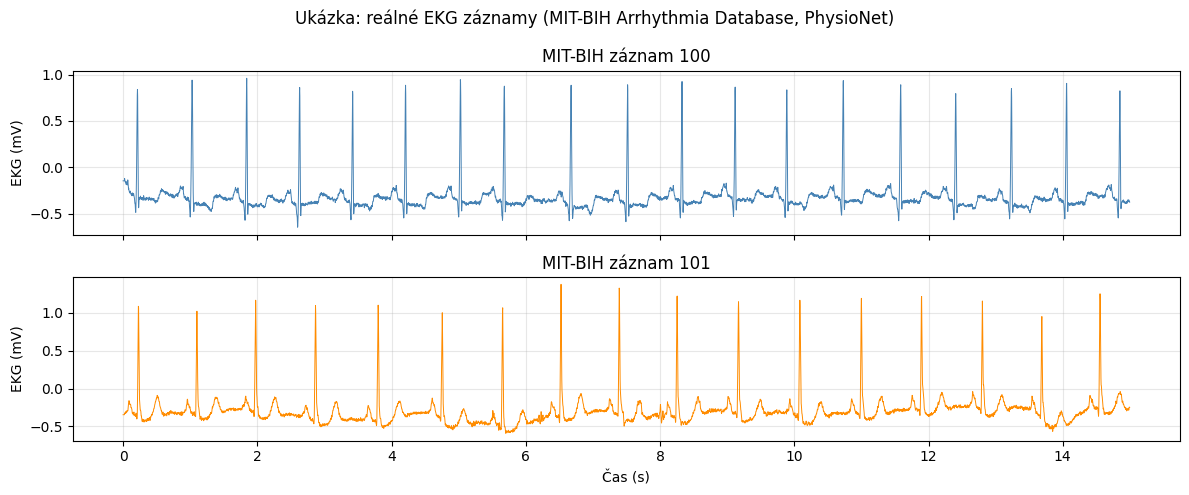

Délka záznamu: 15.0 s, vzorkovací frekvence: 360 Hz


In [1]:
# Ukázkové načtení a zobrazení dvou reálných EKG záznamů pomocí pevně zadané cesty
# Data z MIT-BIH Arrhythmia Database (PhysioNet), fs = 360 Hz
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

data_0 = np.loadtxt("ekg_real/mitbih_100.txt", skiprows=1)
data_1 = np.loadtxt("ekg_real/mitbih_101.txt", skiprows=1)
t0, ekg0 = data_0[:, 0], data_0[:, 1]
t1, ekg1 = data_1[:, 0], data_1[:, 1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(t0, ekg0, linewidth=0.7, color="steelblue")
ax1.set_ylabel("EKG (mV)")
ax1.set_title("MIT-BIH záznam 100")
ax1.grid(True, alpha=0.3)
ax2.plot(t1, ekg1, linewidth=0.7, color="darkorange")
ax2.set_xlabel("Čas (s)")
ax2.set_ylabel("EKG (mV)")
ax2.set_title("MIT-BIH záznam 101")
ax2.grid(True, alpha=0.3)
plt.suptitle("Ukázka: reálné EKG záznamy (MIT-BIH Arrhythmia Database, PhysioNet)")
plt.tight_layout()
plt.show()
print(f"Délka záznamu: {t0[-1]:.1f} s, vzorkovací frekvence: {1/(t0[1]-t0[0]):.0f} Hz")


Načteno 7 klidových a 6 zátěžových záznamů
Délka záznamu: 15.0 s, vzorkovací frekvence: 360 Hz


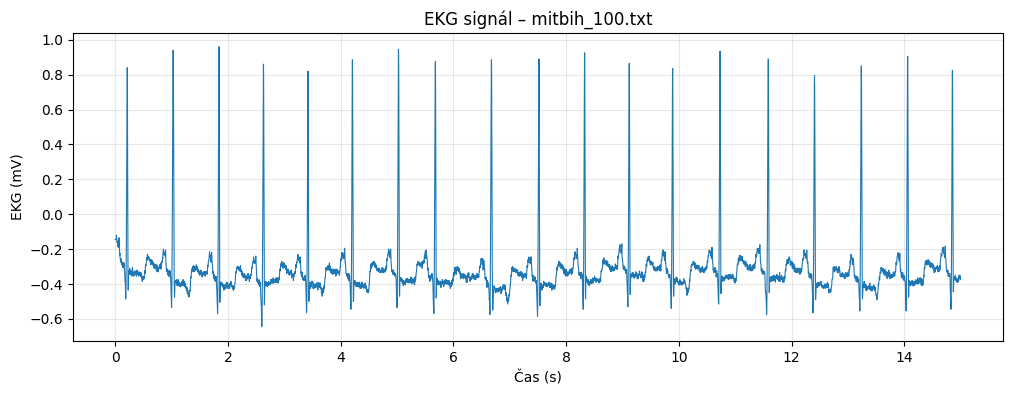

In [5]:
%matplotlib inline
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

# 1) Získej seznamy souborů
files_klid  = sorted(glob.glob("ekg_klid/*.txt"))
files_zatez = sorted(glob.glob("ekg_zatez/*.txt"))

# 2) Načti první klidový záznam a rozbal t a ekg
data0 = np.loadtxt(files_klid[0], skiprows=1)
t   = data0[:, 0]
ekg = data0[:, 1]

print(f"Načteno {len(files_klid)} klidových a {len(files_zatez)} zátěžových záznamů")
print(f"Délka záznamu: {t[-1]:.1f} s, vzorkovací frekvence: {1/(t[1]-t[0]):.0f} Hz")

# 3) Vykresli signál
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, ekg, linewidth=0.8)
ax.set_title(f"EKG signál – {os.path.basename(files_klid[0])}")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("EKG (mV)")
ax.grid(True, alpha=0.3)
plt.show()

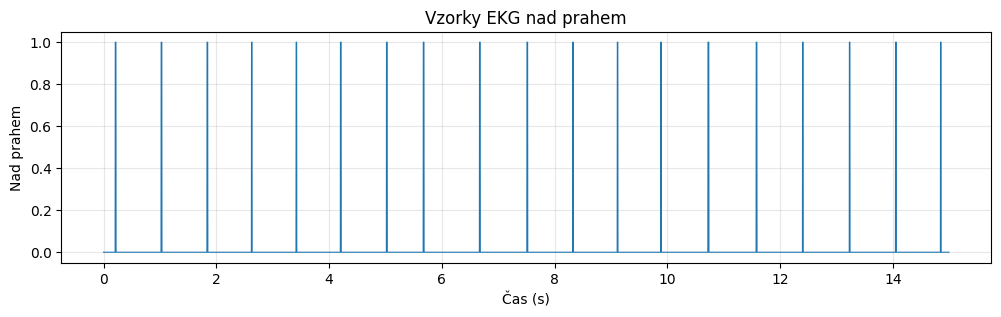

In [6]:
PRAH = 0.5

# 1) Vytvoř logickou masku "ekg nad prahem"
nad_prahem = ekg > PRAH

# 2) Vykresli binární signál nad_prahem v čase
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, nad_prahem.astype(int), linewidth=0.8)
ax.set_title("Vzorky EKG nad prahem")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("Nad prahem")
ax.grid(True, alpha=0.3)
plt.show()

Nalezeno vrcholů: 19


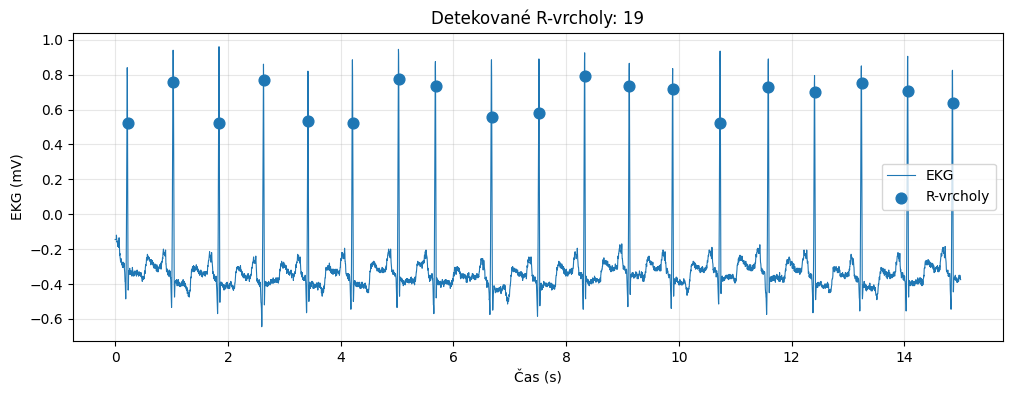

In [7]:
# 1) Detekce R-vrcholů: sestupná hrana
vrcholy_idx = np.where(np.diff(nad_prahem.astype(int)) == -1)[0]

print(f"Nalezeno vrcholů: {len(vrcholy_idx)}")

# 2) Vykresli signál + značky
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, ekg, linewidth=0.8, label="EKG")
ax.scatter(t[vrcholy_idx], ekg[vrcholy_idx], s=60, zorder=5, label="R-vrcholy")
ax.set_title(f"Detekované R-vrcholy: {len(vrcholy_idx)}")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("EKG (mV)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [8]:
cas_vrcholu  = t[vrcholy_idx]
rr_intervaly = np.diff(cas_vrcholu)
tf_bpm       = 60 / rr_intervaly.mean()

print(f"Průměrný R-R interval: {rr_intervaly.mean():.3f} s")
print(f"Tepová frekvence: {tf_bpm:.1f} BPM")

Průměrný R-R interval: 0.813 s
Tepová frekvence: 73.8 BPM


Klidová TF (BPM):  [73.8 67.  62.  65.  68.  63.  67. ]
Zátěžová TF (BPM): [ 65.7  98.  103.  107.   95.  101. ]


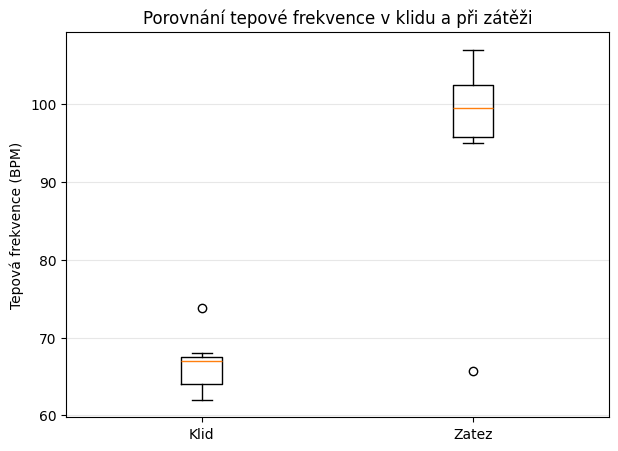

In [10]:
PRAH = 0.5

def spocitej_tf(soubor):
    data = np.loadtxt(soubor, skiprows=1)
    t = data[:, 0]
    ekg = data[:, 1]

    nad_prahem = ekg > PRAH
    vrcholy_idx = np.where(np.diff(nad_prahem.astype(int)) == -1)[0]

    cas_vrcholu = t[vrcholy_idx]
    rr_intervaly = np.diff(cas_vrcholu)

    tf_bpm = 60 / rr_intervaly.mean()
    return tf_bpm

# Projdi všechny soubory v obou skupinách
tf_klid = []
for soubor in files_klid:
    tf_klid.append(spocitej_tf(soubor))

tf_zatez = []
for soubor in files_zatez:
    tf_zatez.append(spocitej_tf(soubor))

tf_klid  = np.array(tf_klid)
tf_zatez = np.array(tf_zatez)

print("Klidová TF (BPM): ", np.round(tf_klid, 1))
print("Zátěžová TF (BPM):", np.round(tf_zatez, 1))

# Boxplot
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([tf_klid, tf_zatez], tick_labels=["Klid", "Zatez"])
ax.set_ylabel("Tepová frekvence (BPM)")
ax.set_title("Porovnání tepové frekvence v klidu a při zátěži")
ax.grid(True, axis="y", alpha=0.3)
plt.show()

##Interpretace
- Krátce komentuj:

Jak se klidová a zátěžová skupina liší v průměrné tepové frekvenci?
Objevil ses outlier? Odkud by mohl pocházet (reálná arytmie, šum, špatně zvolený práh)?
Proč je taková jednoduchá detekce (pevný práh + sestupná hrana) v praxi omezená? Co by bylo potřeba udělat pro robustnější detekci R-vrcholů (filtrace pásmovou propustí, adaptivní práh, Pan–Tompkinsův algoritmus)?

Sem napiš svou odpověď.
- Klidová má nižšiu tep. frek. (60-70) a záťežová vyššiu (95-110)
- Áno, pravdepodobne pre zlú prahovú hodnotu.
- Pretože používa iba pevný prah. v praxi sa odporúča využiť filtráciu signálu alebo adaptívny prah.